<a href="https://colab.research.google.com/github/milleau98/2026-gig-data-analysis/blob/main/notebooks/data-analyses/timeseries_plot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q pandas numpy matplotlib scipy seaborn

In [2]:
import os
from getpass import getpass

TOKEN = getpass('Enter GitHub token: ')
REPO = "milleau98/2026-gig-data-analysis"

if not os.path.exists("2026-gig-data-analysis"):
    !git clone https://{TOKEN}@github.com/{REPO}.git
else:
    %cd 2026-gig-data-analysis
    !git pull

Enter GitHub token: ··········
Cloning into '2026-gig-data-analysis'...
remote: Enumerating objects: 766, done.
remote: Counting objects: 100% (323/323), done.
remote: Compressing objects: 100% (276/276), done.
remote: Total 766 (delta 178), reused 75 (delta 47), pack-reused 443 (from 1)
Receiving objects: 100% (766/766), 49.71 MiB | 16.66 MiB/s, done.
Resolving deltas: 100% (371/371), done.


## Merging Datasets

In [23]:
import pandas as pd

import pandas as pd

# pull in stock price for both gig and S&P 500 yfinance data

gig_stock_df_monthly = pd.read_csv('2026-gig-data-analysis/data/yfinance/gig_yfinance_monthly.csv', parse_dates=['Date'])

sp500_stock_df_monthly = pd.read_csv('2026-gig-data-analysis/data/yfinance/sp500_yfinance_monthly.csv', parse_dates=['Date'])

# combine gig and sp500 stock data

stock_df_monthly = pd.concat([gig_stock_df_monthly, sp500_stock_df_monthly])

# pull in Google trend data

google_df_monthly = pd.read_csv('2026-gig-data-analysis/data/google_trends/google_trends_monthly.csv', parse_dates=['date'])

# pull in FRED data

fred_df_monthly = pd.read_csv('2026-gig-data-analysis/data/fred/fred_monthly_data.csv', parse_dates=['date'])

In [24]:
# make Google trend dataset long to match format of other datasets in order to merge

google_df_monthly_long = google_df_monthly.melt(
    id_vars=['year', 'month'],
    value_vars= ['Uber','Lyft','DoorDash','Instacart','Fiverr','Upwork', 'Nu skin', 'USANA', 'side hustle','gig','Herbalife','Primerica','Etsy', 'Shopify', 'Udemy'],
    var_name = 'company',
    value_name = 'SearchInterest'
)


In [25]:
# rename columns to match across datasets
gig_stock_df_monthly = gig_stock_df_monthly.rename(columns={'Year': 'year'})
sp500_stock_df_monthly = sp500_stock_df_monthly.rename(columns={'Year': 'year'})

stock_df_monthly = stock_df_monthly.rename(columns={'Year':'year', 'Month':'month', 'Company':'company'})

gig_stock_df_monthly = gig_stock_df_monthly.rename(columns={'Month': 'month'})
sp500_stock_df_monthly = sp500_stock_df_monthly.rename(columns={'Month': 'month'})

# only keep necessary columns before merging
monthly_stock_cols = ['year', 'month', 'company','Close']
monthly_fred_cols = ['year', 'month', 'cpi_inflation_data_annual','unemployment_data_monthly', 'cpi_data_monthly', 'rec_smooth_prob_data_monthly', 'rec_nber_data_monthly',
                     'labor_force_participation_data_monthly', 'job_hires_data_monthly', 'gdp_real_data_quarterly', 'm2_real_data_monthly', 'interest_rate_fedfunds_data_monthly',
                     'consumer_sentiment_data_monthly']
monthly_google_cols = ['year', 'month', 'company','SearchInterest']

stock_df_monthly = stock_df_monthly[monthly_stock_cols]

fred_df_monthly = fred_df_monthly[monthly_fred_cols]

google_df_monthly_long = google_df_monthly_long[monthly_google_cols]

# merge all datasets together based on company, year, and month
merged_df_monthly = (
    stock_df_monthly
    .merge(google_df_monthly_long, on=['year','company','month'], how='left')
    .merge(fred_df_monthly, on=['year','month'], how='left'))

# create target variable = close/cpi_data_monthly in order to utilize for correlation analysis

merged_df_monthly['target'] = merged_df_monthly['Close'] / merged_df_monthly['cpi_data_monthly']

merged_df_monthly.head(75)

,year,month,company,Close,SearchInterest,cpi_inflation_data_annual,unemployment_data_monthly,cpi_data_monthly,rec_smooth_prob_data_monthly,rec_nber_data_monthly,labor_force_participation_data_monthly,job_hires_data_monthly,gdp_real_data_quarterly,m2_real_data_monthly,interest_rate_fedfunds_data_monthly,consumer_sentiment_data_monthly,target
0,2018,10,Upwork,19.200001,2.0,2.442583,3.8,252.772,0.46,0.0,62.9,5562.0,20304.874,5640.1,2.19,98.6,0.075958
1,2018,11,Upwork,18.629999,1.0,2.442583,3.8,252.594,0.40,0.0,62.9,5461.0,20304.874,5654.4,2.20,97.5,0.073755
2,2018,12,Upwork,18.110001,1.0,2.442583,3.9,252.767,0.68,0.0,63.0,5400.0,20304.874,5691.7,2.27,98.3,0.071647
3,2019,1,Upwork,19.309999,2.0,1.812210,4.0,252.561,1.76,0.0,63.1,5411.0,20431.641,5725.2,2.40,91.2,0.076457
4,2019,2,Upwork,23.690001,2.0,1.812210,3.8,253.319,1.82,0.0,63.1,5345.0,20431.641,5726.5,2.40,93.8,0.093518
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,2024,8,Upwork,9.640000,3.0,2.949525,4.2,314.062,0.60,0.0,62.7,4846.0,23478.570,6745.7,5.33,67.9,0.030695
71,2024,9,Upwork,10.450000,2.0,2.949525,4.1,314.732,0.68,0.0,62.7,5071.0,23478.570,6757.7,5.13,70.1,0.033203
72,2024,10,Upwork,13.560000,2.0,2.949525,4.1,315.631,0.50,0.0,62.5,4866.0,23586.542,6758.2,4.83,70.5,0.042962
73,2024,11,Upwork,16.969999,2.0,2.949525,4.2,316.528,0.34,0.0,62.4,4820.0,23586.542,6777.2,4.64,71.8,0.053613


In [26]:
# Create transformed variables so that we don't create spurious correlations

df = merged_df_monthly.sort_values(['company','year','month'])

# Stock returns
df['Return'] = df.groupby('company')['Close'].pct_change()
df['Target_change'] = df.groupby('company')['target'].pct_change()

# Search interest change
df['Search_change'] = df.groupby('company')['SearchInterest'].diff()

# Macro changes
df['Inflation_change'] = df['cpi_data_monthly'].pct_change()
df['Unemployment_change'] = df['unemployment_data_monthly'].diff()
df['InterestRate_change'] = df['interest_rate_fedfunds_data_monthly'].diff()
df['ConsumerSentiment_change'] = df['consumer_sentiment_data_monthly'].diff()

df.head()


/tmp/ipykernel_7315/375824016.py:7: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['Target_change'] = df.groupby('company')['target'].pct_change()
/tmp/ipykernel_7315/375824016.py:13: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['Inflation_change'] = df['cpi_data_monthly'].pct_change()


,year,month,company,Close,SearchInterest,cpi_inflation_data_annual,unemployment_data_monthly,cpi_data_monthly,rec_smooth_prob_data_monthly,rec_nber_data_monthly,...,interest_rate_fedfunds_data_monthly,consumer_sentiment_data_monthly,target,Return,Target_change,Search_change,Inflation_change,Unemployment_change,InterestRate_change,ConsumerSentiment_change
1526,2009,1,3M,26.811335,NaN,-0.355546,7.8,211.933,99.74,1.0,...,0.15,61.2,0.126509,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1527,2009,2,3M,22.905647,NaN,-0.355546,8.3,212.705,99.36,1.0,...,0.22,56.3,0.107687,-0.145673,-0.148774,NaN,0.003643,0.5,0.07,-4.9
1528,2009,3,3M,25.052105,NaN,-0.355546,8.7,212.495,99.34,1.0,...,0.18,57.3,0.117895,0.093709,0.094790,NaN,-0.000987,0.4,-0.04,1.0
1529,2009,4,3M,29.022554,NaN,-0.355546,9.0,212.709,96.24,1.0,...,0.15,65.1,0.136443,0.158488,0.157322,NaN,0.001007,0.3,-0.03,7.8
1530,2009,5,3M,29.021479,NaN,-0.355546,9.4,213.022,87.06,1.0,...,0.18,68.7,0.136237,-0.000037,-0.001506,NaN,0.001471,0.4,0.03,3.6


In [27]:
# Create CompanyType Column to split gig/MLM and SP500 Companies
gig_companies = ['Uber','Lyft','DoorDash','Instacart','Grubhub','Fiverr','Upwork',
                 'Etsy','Shopify','Udemy',
                 ]

mlm_companies = ['Herbalife','Primerica','Tupperware','Avon','Nu skin', 'USANA']

def company_type(company):
    if company in gig_companies:
        return 'Gig'
    elif company in mlm_companies:
        return 'MLM'
    else:
        return 'SP500'

df['CompanyType'] = df['company'].apply(company_type)


df.head()

,year,month,company,Close,SearchInterest,cpi_inflation_data_annual,unemployment_data_monthly,cpi_data_monthly,rec_smooth_prob_data_monthly,rec_nber_data_monthly,...,consumer_sentiment_data_monthly,target,Return,Target_change,Search_change,Inflation_change,Unemployment_change,InterestRate_change,ConsumerSentiment_change,CompanyType
1526,2009,1,3M,26.811335,NaN,-0.355546,7.8,211.933,99.74,1.0,...,61.2,0.126509,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SP500
1527,2009,2,3M,22.905647,NaN,-0.355546,8.3,212.705,99.36,1.0,...,56.3,0.107687,-0.145673,-0.148774,NaN,0.003643,0.5,0.07,-4.9,SP500
1528,2009,3,3M,25.052105,NaN,-0.355546,8.7,212.495,99.34,1.0,...,57.3,0.117895,0.093709,0.094790,NaN,-0.000987,0.4,-0.04,1.0,SP500
1529,2009,4,3M,29.022554,NaN,-0.355546,9.0,212.709,96.24,1.0,...,65.1,0.136443,0.158488,0.157322,NaN,0.001007,0.3,-0.03,7.8,SP500
1530,2009,5,3M,29.021479,NaN,-0.355546,9.4,213.022,87.06,1.0,...,68.7,0.136237,-0.000037,-0.001506,NaN,0.001471,0.4,0.03,3.6,SP500


In [28]:
# create dataframe specific to timeseries dataset and chart, including close, search interest, unemployment, and CPI

time_series_df = df.groupby(['year', 'month']).agg({
    'Close':'mean',
    'SearchInterest': 'mean',
    'unemployment_data_monthly' : 'mean',
    'cpi_data_monthly': 'mean',
}).reset_index()

time_series_df.head()

,year,month,Close,SearchInterest,unemployment_data_monthly,cpi_data_monthly
0,2009,1,17.326055,NaN,7.8,211.933
1,2009,2,15.273790,NaN,8.3,212.705
2,2009,3,16.867928,NaN,8.7,212.495
3,2009,4,19.141466,NaN,9.0,212.709
4,2009,5,19.817351,NaN,9.4,213.022


In [29]:
# normalize each company to its own first observation, then average
# take average of search interest variables as well

df['close_norm'] = df.groupby('company')['Close'].transform(lambda x: x/x.dropna().iloc[0])

gig_ts = df[df['CompanyType'] == 'Gig'].groupby(['year','month']).agg({
    'close_norm':'mean',
    'SearchInterest':'mean'
}).reset_index()

mlm_ts = df[df['CompanyType'] == 'MLM'].groupby(['year','month']).agg({
    'close_norm':'mean',
    'SearchInterest':'mean'
}).reset_index()

sp_ts = df[df['CompanyType'] == 'SP500'].groupby(['year','month']).agg({
    'close_norm':'mean'
}).reset_index()

gig_ts.head()

,year,month,close_norm,SearchInterest
0,2015,4,1.000000,53.106383
1,2015,5,0.876799,27.539216
2,2015,6,0.939953,27.463636
3,2015,7,1.155841,28.401639
4,2015,8,0.828417,29.434426


In [30]:
# create dataframe with macroeconomic data

macro_ts = df.groupby(['year','month']).agg({
    'unemployment_data_monthly':'mean',
    'cpi_data_monthly':'mean'
}).reset_index()

macro_ts.head()

,year,month,unemployment_data_monthly,cpi_data_monthly
0,2009,1,7.8,211.933
1,2009,2,8.3,212.705
2,2009,3,8.7,212.495
3,2009,4,9.0,212.709
4,2009,5,9.4,213.022


In [31]:
# create final timeseries datasets to plot

sp_ts = sp_ts.add_suffix('_SP')
sp_ts = sp_ts.rename(columns={'year_SP': 'year', 'month_SP': 'month'})

ts = gig_ts.merge(mlm_ts, on=['year','month'], suffixes=('_Gig','_MLM'))
ts = ts.merge(sp_ts, on=['year', 'month'], suffixes=('', '_SP'))
ts = ts.merge(macro_ts, on=['year','month'])

ts

,year,month,close_norm_Gig,SearchInterest_Gig,close_norm_MLM,SearchInterest_MLM,close_norm_SP,unemployment_data_monthly,cpi_data_monthly
0,2015,4,1.000000,53.106383,3.820627,3.000000,4.253624,5.4,236.222
1,2015,5,0.876799,27.539216,4.382435,3.000000,4.361405,5.6,237.001
2,2015,6,0.939953,27.463636,4.638319,2.666667,4.305222,5.3,237.657
3,2015,7,1.155841,28.401639,4.291650,3.000000,4.383726,5.2,238.034
4,2015,8,0.828417,29.434426,4.825100,3.000000,4.164476,5.1,238.033
...,...,...,...,...,...,...,...,...,...
124,2025,8,6.419458,29.746154,6.126074,1.666667,19.496948,4.3,323.291
125,2025,9,6.793859,28.145161,6.041053,1.333333,20.059488,4.4,324.245
126,2025,10,7.656728,28.947619,5.529297,1.000000,20.266108,NaN,NaN
127,2025,11,7.008484,30.295082,5.810865,1.333333,20.047507,4.5,325.063


In [32]:
# Normalize variables

ts['Gig_norm'] = ts['close_norm_Gig'] / ts['close_norm_Gig'].dropna().iloc[0]
ts['MLM_norm'] = ts['close_norm_MLM'] / ts['close_norm_MLM'].dropna().iloc[0]
ts['SP_norm'] = ts['close_norm_SP'] / ts['close_norm_SP'].dropna().iloc[0]
ts['Gig_Search_norm'] = ts['SearchInterest_Gig'] / ts['SearchInterest_Gig'].iloc[0]
ts['MLM_Search_norm'] = ts['SearchInterest_MLM'] / ts['SearchInterest_MLM'].iloc[0]
ts['Unemployment_norm'] = ts['unemployment_data_monthly'] / ts['unemployment_data_monthly'].iloc[0]
ts['CPI_norm'] = ts['cpi_data_monthly'] / ts['cpi_data_monthly'].iloc[0]

ts

,year,month,close_norm_Gig,SearchInterest_Gig,close_norm_MLM,SearchInterest_MLM,close_norm_SP,unemployment_data_monthly,cpi_data_monthly,Gig_norm,MLM_norm,SP_norm,Gig_Search_norm,MLM_Search_norm,Unemployment_norm,CPI_norm
0,2015,4,1.000000,53.106383,3.820627,3.000000,4.253624,5.4,236.222,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
1,2015,5,0.876799,27.539216,4.382435,3.000000,4.361405,5.6,237.001,0.876799,1.147046,1.025339,0.518567,1.000000,1.037037,1.003298
2,2015,6,0.939953,27.463636,4.638319,2.666667,4.305222,5.3,237.657,0.939953,1.214020,1.012130,0.517144,0.888889,0.981481,1.006075
3,2015,7,1.155841,28.401639,4.291650,3.000000,4.383726,5.2,238.034,1.155841,1.123284,1.030586,0.534807,1.000000,0.962963,1.007671
4,2015,8,0.828417,29.434426,4.825100,3.000000,4.164476,5.1,238.033,0.828417,1.262908,0.979042,0.554254,1.000000,0.944444,1.007667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124,2025,8,6.419458,29.746154,6.126074,1.666667,19.496948,4.3,323.291,6.419458,1.603421,4.583608,0.560124,0.555556,0.796296,1.368590
125,2025,9,6.793859,28.145161,6.041053,1.333333,20.059488,4.4,324.245,6.793859,1.581168,4.715858,0.529977,0.444444,0.814815,1.372628
126,2025,10,7.656728,28.947619,5.529297,1.000000,20.266108,NaN,NaN,7.656728,1.447222,4.764433,0.545087,0.333333,NaN,NaN
127,2025,11,7.008484,30.295082,5.810865,1.333333,20.047507,4.5,325.063,7.008484,1.520919,4.713041,0.570460,0.444444,0.833333,1.376091


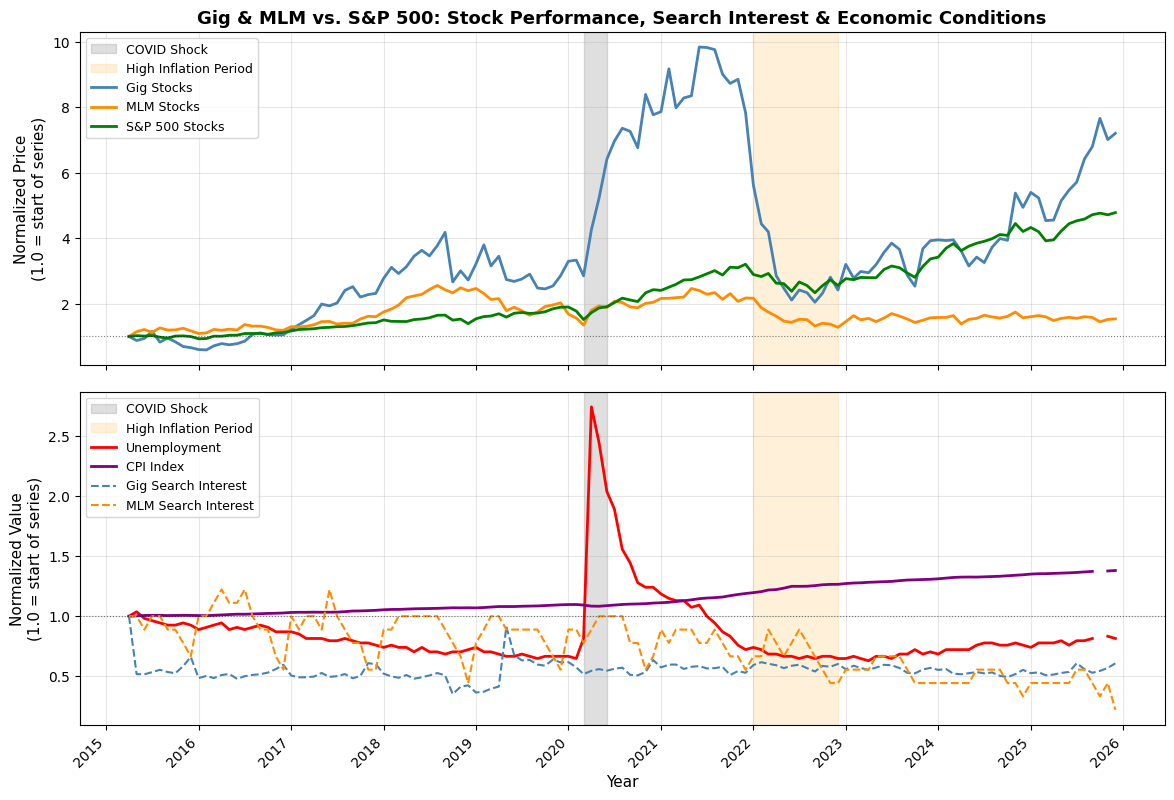

In [33]:
# Make sure you have a datetime column
ts['date'] = pd.to_datetime(ts[['year', 'month']].assign(day=1))

# two stacked subplots sharing the same x-axis
# top panel: stock performance by group
# bottom panel: macro conditions + search interest


fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(14, 9),
    sharex=True,
    gridspec_kw={'hspace': 0.08}
)

# shaded regions (applied to both axes)

for ax in [ax1, ax2]:
    ax.axvspan(pd.to_datetime('2020-03-01'),
               pd.to_datetime('2020-06-01'),
               color='gray', alpha=0.25, label='COVID Shock')
    ax.axvspan(pd.to_datetime('2022-01-01'),
               pd.to_datetime('2022-12-01'),
               color='orange', alpha=0.15, label='High Inflation Period')

# top panel: normalized stock prices by group


ax1.plot(ts['date'], ts['Gig_norm'],  label='Gig Stocks',    color='steelblue',  linewidth=2)
ax1.plot(ts['date'], ts['MLM_norm'],  label='MLM Stocks',    color='darkorange', linewidth=2)
ax1.plot(ts['date'], ts['SP_norm'],   label='S&P 500 Stocks',color='green',      linewidth=2)

ax1.axhline(1.0, color='black', linestyle=':', linewidth=0.8, alpha=0.5)  # baseline reference

ax1.set_ylabel('Normalized Price\n(1.0 = start of series)', fontsize=11)
ax1.set_title('Gig & MLM vs. S&P 500: Stock Performance, Search Interest & Economic Conditions',
              fontsize=13, fontweight='bold')
ax1.legend(loc='upper left', fontsize=9)
ax1.grid(True, alpha=0.3)

# bottom panel: Macro indicators + search interest

ax2.plot(ts['date'], ts['Unemployment_norm'], label='Unemployment',      color='red',    linewidth=2)
ax2.plot(ts['date'], ts['CPI_norm'],          label='CPI Index',         color='purple', linewidth=2)
ax2.plot(ts['date'], ts['Gig_Search_norm'],   label='Gig Search Interest',  color='steelblue', linewidth=1.5, linestyle='--')
ax2.plot(ts['date'], ts['MLM_Search_norm'],   label='MLM Search Interest',  color='darkorange', linewidth=1.5, linestyle='--')

ax2.axhline(1.0, color='black', linestyle=':', linewidth=0.8, alpha=0.5)  # baseline reference

ax2.set_ylabel('Normalized Value\n(1.0 = start of series)', fontsize=11)
ax2.set_xlabel('Year', fontsize=11)
ax2.legend(loc='upper left', fontsize=9)
ax2.grid(True, alpha=0.3)

#x-axis formatting (only needed on bottom panel since sharex=True)

ax2.xaxis.set_major_locator(mdates.YearLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45, ha='right')

# add shaded region labels only once (in bottom panel legend)
# the handles are already added via the loop above

plt.subplots_adjust(hspace=0.08)
plt.show()